# Validation Results

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# Support execution from either the notebook directory or the repository root.
experiment_dir = Path.cwd()
if not (experiment_dir / "validation_results.ipynb").exists():
    experiment_dir = experiment_dir / "experiments" / "1_determine_initial_pool"
runs_dir = experiment_dir / "runs"

records = []
skipped_runs = []
for history_path in sorted(runs_dir.glob("*/history.json")):
    run_dir = history_path.parent
    config_path = run_dir / "config.json"
    try:
        with config_path.open() as file:
            config = json.load(file)
        with history_path.open() as file:
            history = json.load(file)
        if not history:
            raise ValueError("history is empty")
        result = history[-1]
        records.append({
            "run": run_dir.name,
            "initial_pool_pct": float(config["initial_labeled_pool_size"]),
            "seed": int(config["seed"]),
            "labeled_budget_pct": float(result["labeled_budget_percent"]),
            "labeled_frames": int(result["labeled_pool_frames"]),
            "labeled_clips": int(result["labeled_pool_size"]),
            "val_edit": float(result["val_edit"]),
            "val_f1_event": float(result["val_f1_event"]),
            "val_f1_element": float(result["val_f1_element"]),
        })
    except (OSError, ValueError, TypeError, KeyError, json.JSONDecodeError) as error:
        skipped_runs.append((run_dir.name, str(error)))

results_df = pd.DataFrame.from_records(records)
if results_df.empty:
    raise FileNotFoundError(f"No completed run histories found under {runs_dir.resolve()}")
results_df = results_df.sort_values(["initial_pool_pct", "seed"]).reset_index(drop=True)

def plot_validation_metrics(x_column):
    """Plot all validation metrics side by side against the selected budget measure."""
    x_labels = {
        "labeled_budget_pct": "Labeled training frames (%)",
        "labeled_frames": "Labeled training frames",
        "labeled_clips": "Number of labeled clips",
    }
    metric_config = {
        "val_edit": ("Validation edit score", (0, 100)),
        "val_f1_event": ("Validation event F1", (0, 1)),
        "val_f1_element": ("Validation element F1", (0, 1)),
    }
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    summaries = {}
    for ax, (metric, (title, limits)) in zip(axes, metric_config.items()):
        summary = (results_df.groupby("initial_pool_pct", sort=True)
                   .agg(x_mean=(x_column, "mean"), score_mean=(metric, "mean"),
                        score_std=(metric, "std"), n=("run", "nunique"))
                   .reset_index())
        summaries[metric] = summary
        ax.scatter(results_df[x_column], results_df[metric], color="#4c78a8",
                   alpha=0.4, s=30, label="Individual seeds", zorder=2)
        ax.errorbar(summary["x_mean"], summary["score_mean"],
                    yerr=summary["score_std"].fillna(0), color="#e45756",
                    marker="o", markersize=5, linewidth=2, capsize=4,
                    label="Mean +/- 1 SD", zorder=3)
        ax.set(title=title, xlabel=x_labels[x_column], ylabel=title, ylim=limits)
        ax.ticklabel_format(axis="x", style="plain", useOffset=False)
        ax.grid(alpha=0.25)
    axes[0].legend()
    fig.tight_layout()
    plt.show()
    return summaries

print(f"Loaded {results_df['run'].nunique()} completed run(s) from {runs_dir.resolve()}")
if skipped_runs:
    print(f"Skipped {len(skipped_runs)} incomplete or malformed run(s):")
    for run, reason in skipped_runs:
        print(f"  {run}: {reason}")

Loaded 60 completed run(s) from /mnt/ssd2/zachary/alpes/experiments/1_determine_initial_pool/runs


## Performance vs. Annotation Budget (no. of frames)

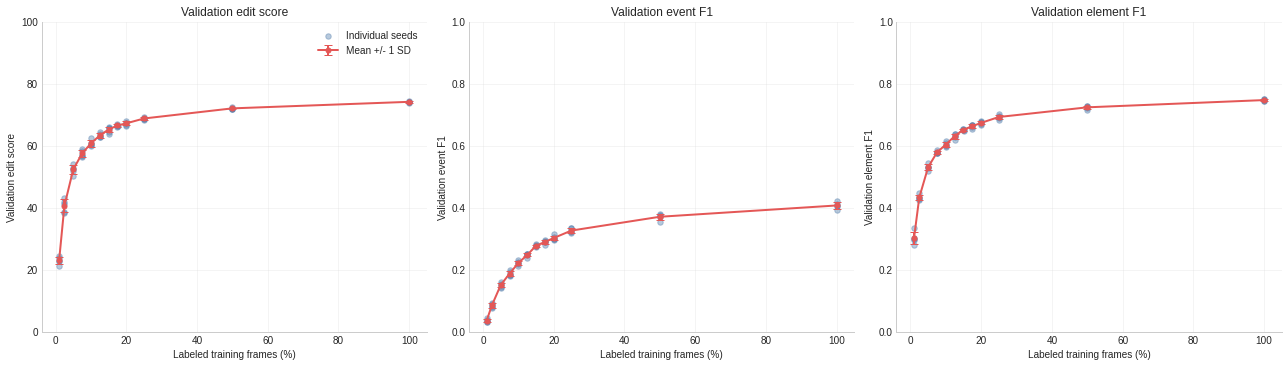

In [2]:
plot_validation_metrics("labeled_budget_pct");

## Performance vs. No. of Clips

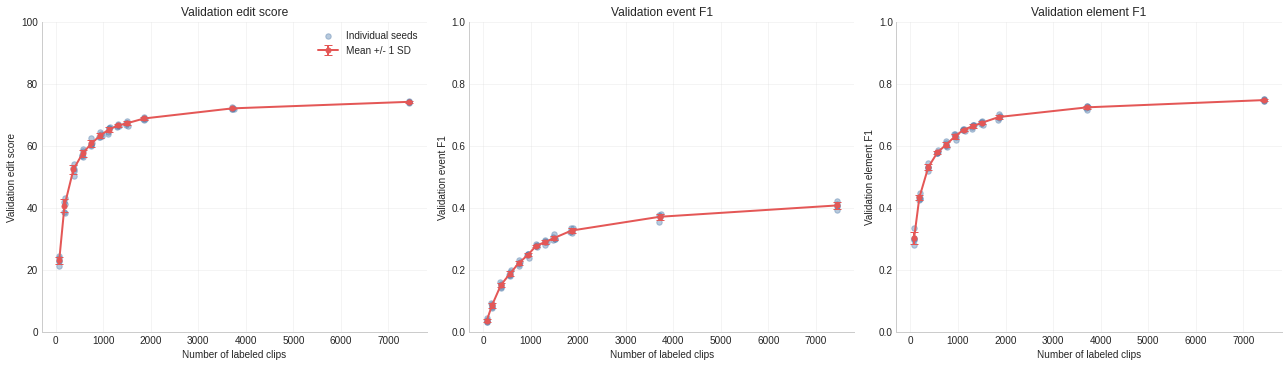

In [3]:
plot_validation_metrics("labeled_clips");